# Business Case 2 — Intelligent Staffing Optimization

## Business Objective

Forecast daily appointment volume to support healthcare staffing and capacity planning.

The objective is to help management:

- Estimate upcoming appointment demand
- Plan specialist staffing levels
- Balance workload across morning and afternoon shifts
- Reduce understaffing and excess capacity

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
df_business = pd.read_csv("../../data/Medical_appointment_data.csv")

print("Dataset shape:", df_business.shape)

Dataset shape: (109593, 26)


In [2]:
# Create a working copy
df = df_business.copy()

# Convert appointment date to datetime
df['appointment_date_continuous'] = pd.to_datetime(
    df['appointment_date_continuous'],
    errors='coerce'
)

# Remove duplicate rows
df = df.drop_duplicates()

print("Cleaned dataset shape:", df.shape)
print("Date range:", df['appointment_date_continuous'].min(), "to",
      df['appointment_date_continuous'].max())
print("Missing dates:", df['appointment_date_continuous'].isna().sum())

Cleaned dataset shape: (109557, 26)
Date range: 2020-01-01 00:00:00 to 2021-05-12 00:00:00
Missing dates: 0


In [3]:
# Calculate daily appointment volume

daily_volume = (
    df.groupby('appointment_date_continuous')
      .size()
      .reset_index(name='appointment_volume')
      .sort_values('appointment_date_continuous')
)

print("Number of days:", len(daily_volume))
print("\nDaily volume summary:")
print(daily_volume['appointment_volume'].describe())

print("\nFirst 10 days:")
print(daily_volume.head(10))

Number of days: 498

Daily volume summary:
count     498.000000
mean      219.993976
std       245.678124
min         1.000000
25%        10.000000
50%       126.500000
75%       393.250000
max      1510.000000
Name: appointment_volume, dtype: float64

First 10 days:
  appointment_date_continuous  appointment_volume
0                  2020-01-01                  25
1                  2020-01-02                  33
2                  2020-01-03                  18
3                  2020-01-04                  16
4                  2020-01-05                  15
5                  2020-01-06                   2
6                  2020-01-07                   7
7                  2020-01-08                  32
8                  2020-01-09                  17
9                  2020-01-10                  38


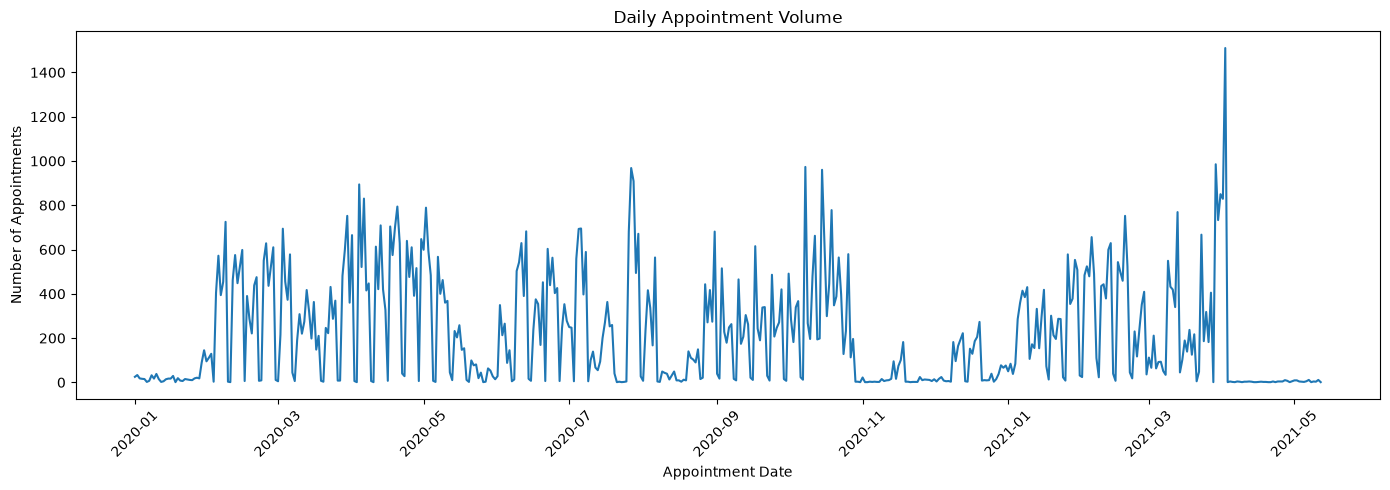

In [4]:
# Plot daily appointment volume

plt.figure(figsize=(14, 5))

plt.plot(
    daily_volume['appointment_date_continuous'],
    daily_volume['appointment_volume']
)

plt.xlabel('Appointment Date')
plt.ylabel('Number of Appointments')
plt.title('Daily Appointment Volume')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [5]:
# Analyze appointment volume by day of the week

daily_volume['day_of_week'] = (
    daily_volume['appointment_date_continuous']
    .dt.day_name()
)

weekday_order = [
    'Monday',
    'Tuesday',
    'Wednesday',
    'Thursday',
    'Friday',
    'Saturday',
    'Sunday'
]

weekly_demand = (
    daily_volume.groupby('day_of_week')['appointment_volume']
    .mean()
    .reindex(weekday_order)
)

print("Average appointments per day by weekday:")
print(weekly_demand.round(2))

Average appointments per day by weekday:
day_of_week
Monday       228.68
Tuesday      218.82
Wednesday    199.03
Thursday     258.72
Friday       239.77
Saturday     238.99
Sunday       156.25
Name: appointment_volume, dtype: float64


In [6]:
# Analyze appointment volume by shift

shift_demand = (
    df.groupby('appointment_shift')
      .size()
      .reset_index(name='appointment_volume')
      .sort_values('appointment_volume', ascending=False)
)

print("Appointment volume by shift:")
print(shift_demand)

Appointment volume by shift:
  appointment_shift  appointment_volume
0         afternoon               59321
1           morning               50236


In [7]:
# Analyze appointment volume by specialty and shift

specialty_shift_demand = (
    df.groupby(['specialty', 'appointment_shift'])
      .size()
      .reset_index(name='appointment_volume')
      .sort_values('appointment_volume', ascending=False)
)

print("Appointment volume by specialty and shift:")
print(specialty_shift_demand)

Appointment volume by specialty and shift:
               specialty appointment_shift  appointment_volume
10         psychotherapy         afternoon               17905
14        speech therapy         afternoon               13747
9          physiotherapy           morning               10811
11         psychotherapy           morning               10737
8          physiotherapy         afternoon               10190
15        speech therapy           morning                8574
4   occupational therapy         afternoon                7192
5   occupational therapy           morning                4126
6               pedagogo         afternoon                3518
3                    enf           morning                1601
1                 assist           morning                 594
12     sem especialidade         afternoon                 294
2                    enf         afternoon                  80
0                 assist         afternoon                  41
13     sem e

In [8]:
# Create specialty-wise staffing demand by shift

staffing_table = (
    df.groupby(['specialty', 'appointment_shift'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)

# Calculate total demand
staffing_table['Total Appointments'] = (
    staffing_table.get('morning', 0) +
    staffing_table.get('afternoon', 0)
)

# Sort by total demand
staffing_table = staffing_table.sort_values(
    'Total Appointments',
    ascending=False
)

print(staffing_table.to_string(index=False))

           specialty  afternoon  morning  Total Appointments
       psychotherapy      17905    10737               28642
      speech therapy      13747     8574               22321
       physiotherapy      10190    10811               21001
occupational therapy       7192     4126               11318
            pedagogo       3518       17                3535
                 enf         80     1601                1681
              assist         41      594                 635
   sem especialidade        294       30                 324


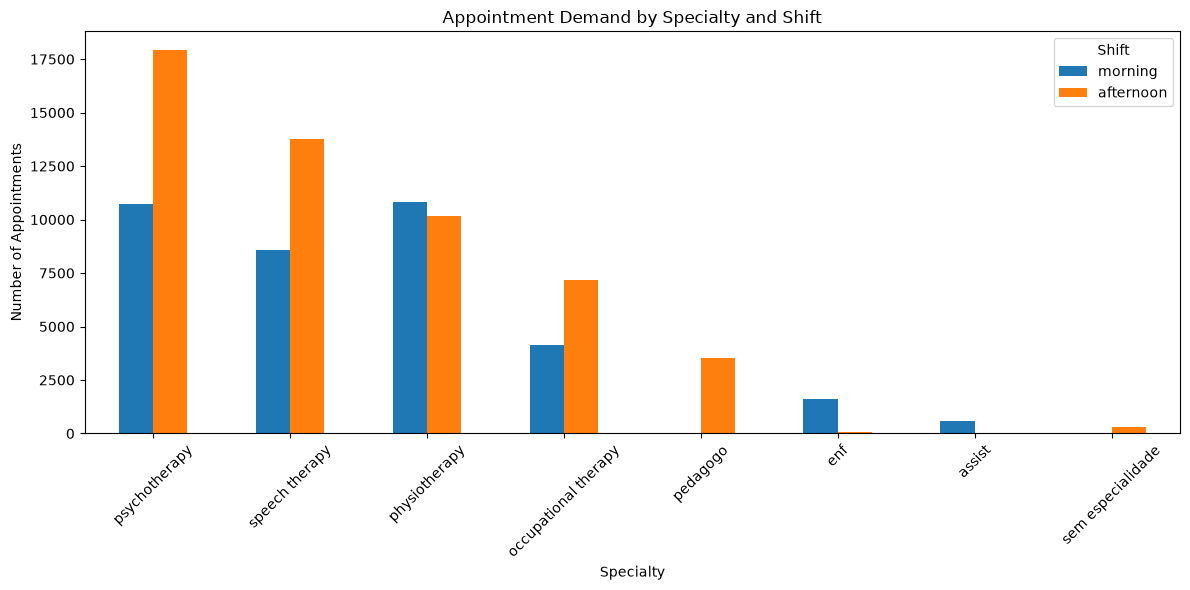

In [9]:
# Visualize specialty demand by shift

staffing_plot = staffing_table.set_index('specialty')[
    ['morning', 'afternoon']
]

staffing_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel('Specialty')
plt.ylabel('Number of Appointments')
plt.title('Appointment Demand by Specialty and Shift')
plt.xticks(rotation=45)
plt.legend(title='Shift')
plt.tight_layout()
plt.show()

In [10]:
# Prepare daily appointment volume as a time series

daily_ts = daily_volume[
    ['appointment_date_continuous', 'appointment_volume']
].copy()

daily_ts = daily_ts.set_index('appointment_date_continuous')

# Create a complete daily date range
full_date_range = pd.date_range(
    start=daily_ts.index.min(),
    end=daily_ts.index.max(),
    freq='D'
)

daily_ts = daily_ts.reindex(full_date_range)

# Rename index
daily_ts.index.name = 'appointment_date'

# Fill days with no scheduled appointments as zero
daily_ts['appointment_volume'] = (
    daily_ts['appointment_volume']
    .fillna(0)
)

print("Date range:", daily_ts.index.min(), "to", daily_ts.index.max())
print("Total calendar days:", len(daily_ts))
print("Days with appointments:", (daily_ts['appointment_volume'] > 0).sum())
print("Days with zero appointments:", (daily_ts['appointment_volume'] == 0).sum())

Date range: 2020-01-01 00:00:00 to 2021-05-12 00:00:00
Total calendar days: 498
Days with appointments: 498
Days with zero appointments: 0


In [11]:
# Calculate 7-day rolling average

daily_ts['rolling_7_day'] = (
    daily_ts['appointment_volume']
    .rolling(window=7)
    .mean()
)

print("Daily volume statistics:")
print(daily_ts['appointment_volume'].describe())

print("\nHighest appointment volume days:")
print(
    daily_ts.nlargest(5, 'appointment_volume')
    [['appointment_volume']]
)

print("\nLowest appointment volume days:")
print(
    daily_ts.nsmallest(5, 'appointment_volume')
    [['appointment_volume']]
)

Daily volume statistics:
count     498.000000
mean      219.993976
std       245.678124
min         1.000000
25%        10.000000
50%       126.500000
75%       393.250000
max      1510.000000
Name: appointment_volume, dtype: float64

Highest appointment volume days:
                  appointment_volume
appointment_date                    
2021-04-02                      1510
2021-03-29                       985
2020-10-08                       973
2020-07-27                       968
2020-10-15                       960

Lowest appointment volume days:
                  appointment_volume
appointment_date                    
2020-01-18                         1
2020-02-10                         1
2020-04-03                         1
2020-04-10                         1
2020-05-26                         1


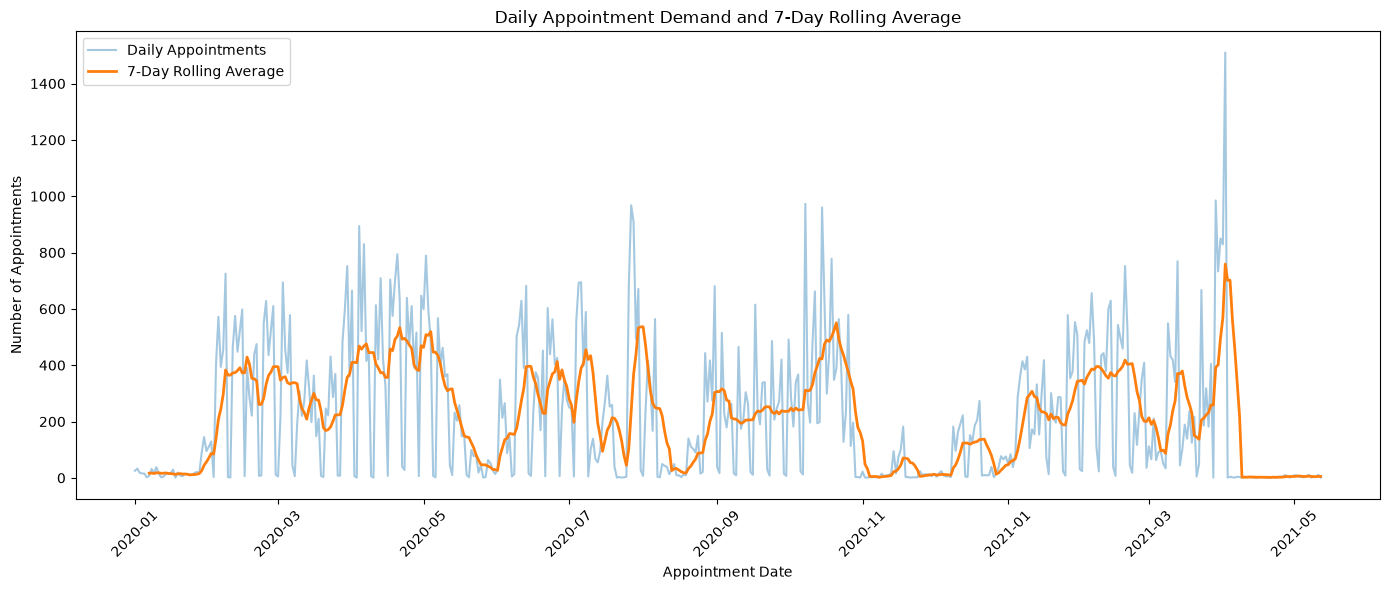

In [12]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily_ts.index,
    daily_ts['appointment_volume'],
    alpha=0.4,
    label='Daily Appointments'
)

plt.plot(
    daily_ts.index,
    daily_ts['rolling_7_day'],
    linewidth=2,
    label='7-Day Rolling Average'
)

plt.xlabel('Appointment Date')
plt.ylabel('Number of Appointments')
plt.title('Daily Appointment Demand and 7-Day Rolling Average')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [13]:
# Chronological train-test split
# Last 30 days = test set

test_days = 30

train_ts = daily_ts.iloc[:-test_days].copy()
test_ts = daily_ts.iloc[-test_days:].copy()

print("Training period:")
print(train_ts.index.min(), "to", train_ts.index.max())

print("\nTest period:")
print(test_ts.index.min(), "to", test_ts.index.max())

print("\nTraining days:", len(train_ts))
print("Test days:", len(test_ts))

Training period:
2020-01-01 00:00:00 to 2021-04-12 00:00:00

Test period:
2021-04-13 00:00:00 to 2021-05-12 00:00:00

Training days: 468
Test days: 30


In [17]:
import sys

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

Python executable:
c:\Users\sadhu\AppData\Local\Programs\Python\Python314\python.exe

Python version:
3.14.5 (tags/v3.14.5:5607950, May 10 2026, 10:43:50) [MSC v.1944 64 bit (AMD64)]


In [18]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

print("Exponential Smoothing imported successfully.")

Exponential Smoothing imported successfully.


In [19]:
# Holt-Winters Exponential Smoothing model

model = ExponentialSmoothing(
    train_ts['appointment_volume'],
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

fitted_model = model.fit(optimized=True)

print("Holt-Winters model trained successfully.")

Holt-Winters model trained successfully.


In [20]:
# Forecast the next 30 days

forecast = fitted_model.forecast(steps=len(test_ts))

# Store predictions in the test dataframe
test_ts['forecast'] = forecast

print("Forecast generated successfully.")
print("\nFirst 10 predictions:")
print(test_ts[['appointment_volume', 'forecast']].head(10).round(2))

Forecast generated successfully.

First 10 predictions:
                  appointment_volume  forecast
appointment_date                              
2021-04-13                         3    142.63
2021-04-14                         1    102.85
2021-04-15                         1    128.27
2021-04-16                         2    250.73
2021-04-17                         3     30.09
2021-04-18                         2   -131.77
2021-04-19                         2     15.31
2021-04-20                         1    143.65
2021-04-21                         1    103.87
2021-04-22                         4    129.28


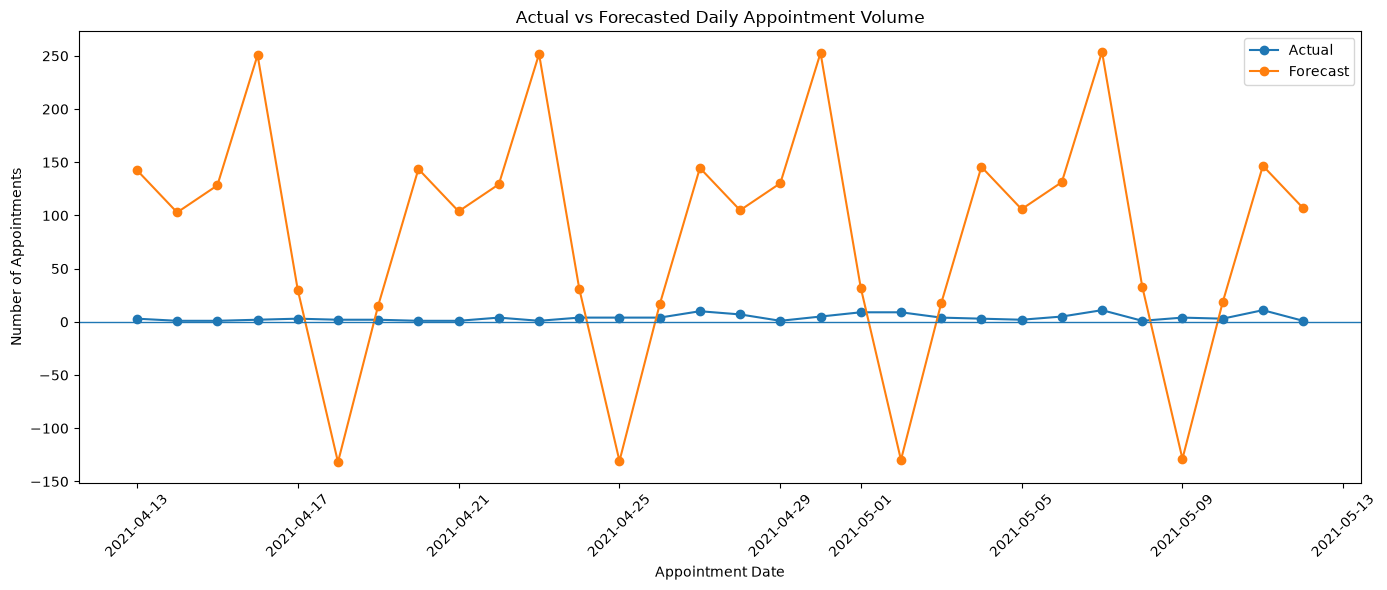

In [21]:
# Compare actual and forecast appointment volume

plt.figure(figsize=(14, 6))

plt.plot(
    test_ts.index,
    test_ts['appointment_volume'],
    marker='o',
    label='Actual'
)

plt.plot(
    test_ts.index,
    test_ts['forecast'],
    marker='o',
    label='Forecast'
)

plt.axhline(0, linewidth=1)

plt.xlabel('Appointment Date')
plt.ylabel('Number of Appointments')
plt.title('Actual vs Forecasted Daily Appointment Volume')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(
    test_ts['appointment_volume'],
    test_ts['forecast']
)

rmse = np.sqrt(
    mean_squared_error(
        test_ts['appointment_volume'],
        test_ts['forecast']
    )
)

print("Forecast Accuracy:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))

Forecast Accuracy:
MAE : 113.66
RMSE: 133.62


In [23]:
# Holt-Winters model with log-transformed appointment volume

train_log = np.log1p(train_ts['appointment_volume'])

log_model = ExponentialSmoothing(
    train_log,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

log_fitted_model = log_model.fit(optimized=True)

# Forecast on log scale
log_forecast = log_fitted_model.forecast(steps=len(test_ts))

# Convert back to original scale
log_forecast = np.expm1(log_forecast)

# Prevent any tiny negative numerical values
log_forecast = np.maximum(log_forecast, 0)

test_ts['log_forecast'] = log_forecast

print("Log-transformed Holt-Winters forecast generated successfully.")
print("\nFirst 10 predictions:")
print(
    test_ts[['appointment_volume', 'log_forecast']]
    .head(10)
    .round(2)
)

Log-transformed Holt-Winters forecast generated successfully.

First 10 predictions:
                  appointment_volume  log_forecast
appointment_date                                  
2021-04-13                         3          6.17
2021-04-14                         1         10.41
2021-04-15                         1         11.85
2021-04-16                         2         10.27
2021-04-17                         3          3.31
2021-04-18                         2          0.60
2021-04-19                         2          2.80
2021-04-20                         1          6.07
2021-04-21                         1         10.26
2021-04-22                         4         11.68


In [24]:
# Evaluate log-transformed forecast

log_mae = mean_absolute_error(
    test_ts['appointment_volume'],
    test_ts['log_forecast']
)

log_rmse = np.sqrt(
    mean_squared_error(
        test_ts['appointment_volume'],
        test_ts['log_forecast']
    )
)

print("Log-transformed Holt-Winters Accuracy:")
print("MAE :", round(log_mae, 2))
print("RMSE:", round(log_rmse, 2))

print("\nOriginal Holt-Winters:")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))

Log-transformed Holt-Winters Accuracy:
MAE : 4.91
RMSE: 5.94

Original Holt-Winters:
MAE : 113.66
RMSE: 133.62


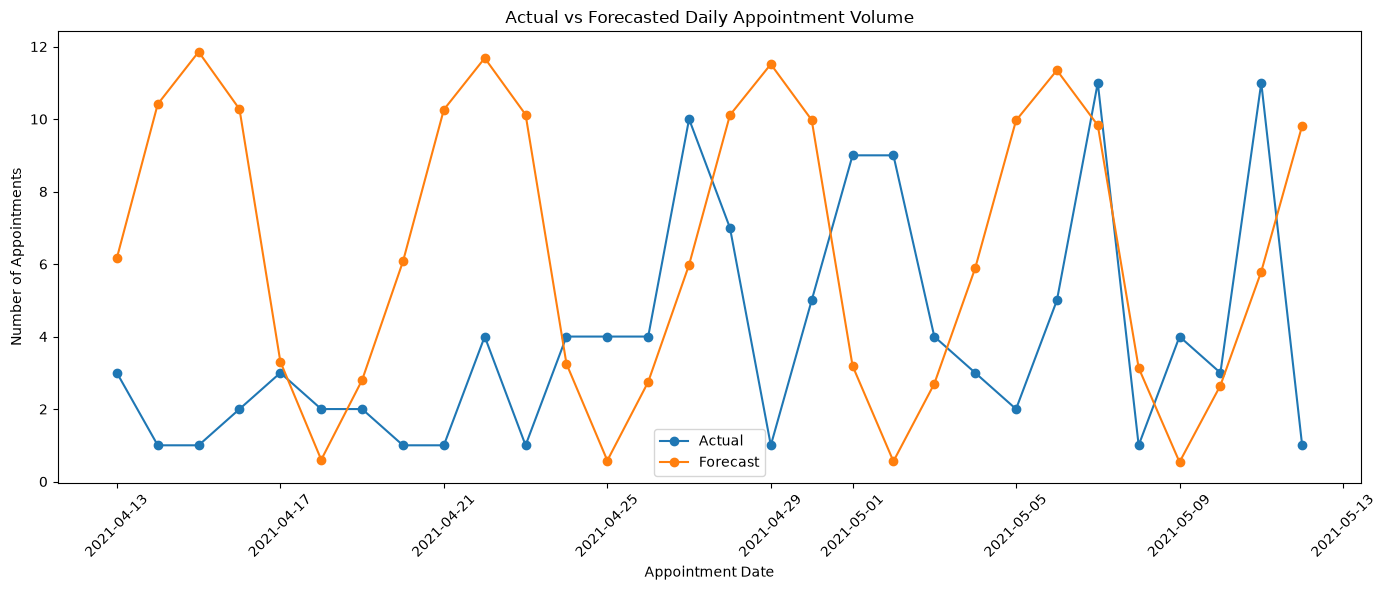

In [25]:
# Actual vs Log-Transformed Holt-Winters Forecast

plt.figure(figsize=(14, 6))

plt.plot(
    test_ts.index,
    test_ts['appointment_volume'],
    marker='o',
    label='Actual'
)

plt.plot(
    test_ts.index,
    test_ts['log_forecast'],
    marker='o',
    label='Forecast'
)

plt.xlabel('Appointment Date')
plt.ylabel('Number of Appointments')
plt.title('Actual vs Forecasted Daily Appointment Volume')

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [26]:
# Train final forecasting model using all available historical data

full_log = np.log1p(daily_ts['appointment_volume'])

final_model = ExponentialSmoothing(
    full_log,
    trend='add',
    seasonal='add',
    seasonal_periods=7
)

final_fitted_model = final_model.fit(optimized=True)

# Forecast next 14 days
future_forecast_log = final_fitted_model.forecast(steps=14)

# Convert predictions back to original scale
future_forecast = np.expm1(future_forecast_log)

# Ensure forecasts are non-negative
future_forecast = np.maximum(future_forecast, 0)

future_dates = pd.date_range(
    start=daily_ts.index.max() + pd.Timedelta(days=1),
    periods=14,
    freq='D'
)

future_forecast_df = pd.DataFrame({
    'appointment_date': future_dates,
    'forecasted_appointments': future_forecast
})

print("14-day staffing forecast:")
print(future_forecast_df.round(2).to_string(index=False))

14-day staffing forecast:
appointment_date  forecasted_appointments
      2021-05-13                     3.38
      2021-05-14                     6.03
      2021-05-15                     2.92
      2021-05-16                     4.16
      2021-05-17                     3.07
      2021-05-18                     5.56
      2021-05-19                     2.66
      2021-05-20                     3.31
      2021-05-21                     5.92
      2021-05-22                     2.85
      2021-05-23                     4.08
      2021-05-24                     3.00
      2021-05-25                     5.45
      2021-05-26                     2.60


C:\Users\sadhu\AppData\Local\Temp\ipykernel_2864\993831245.py:35: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  print(future_forecast_df.round(2).to_string(index=False))


In [27]:
# Inspect the last 30 historical days

recent_demand = daily_ts[
    ['appointment_volume']
].tail(30)

print("Last 30 historical days:")
print(recent_demand.to_string())

print("\nRecent 30-day average:",
      round(recent_demand['appointment_volume'].mean(), 2))

print("Recent 30-day median:",
      round(recent_demand['appointment_volume'].median(), 2))

Last 30 historical days:
                  appointment_volume
appointment_date                    
2021-04-13                         3
2021-04-14                         1
2021-04-15                         1
2021-04-16                         2
2021-04-17                         3
2021-04-18                         2
2021-04-19                         2
2021-04-20                         1
2021-04-21                         1
2021-04-22                         4
2021-04-23                         1
2021-04-24                         4
2021-04-25                         4
2021-04-26                         4
2021-04-27                        10
2021-04-28                         7
2021-04-29                         1
2021-04-30                         5
2021-05-01                         9
2021-05-02                         9
2021-05-03                         4
2021-05-04                         3
2021-05-05                         2
2021-05-06                         5
2021-05-07   

In [28]:
# Monthly appointment demand

monthly_demand = (
    df.assign(
        appointment_month_date=df['appointment_date_continuous']
        .dt.to_period('M')
        .dt.to_timestamp()
    )
    .groupby('appointment_month_date')
    .size()
    .reset_index(name='appointment_volume')
)

print(monthly_demand.to_string(index=False))

appointment_month_date  appointment_volume
            2020-01-01                 772
            2020-02-01                9992
            2020-03-01                8794
            2020-04-01               13036
            2020-05-01                6175
            2020-06-01                8782
            2020-07-01                9039
            2020-08-01                4711
            2020-09-01                6373
            2020-10-01               10735
            2020-11-01                 649
            2020-12-01                2241
            2021-01-01                7565
            2021-02-01                9544
            2021-03-01                8665
            2021-04-01                2421
            2021-05-01                  63


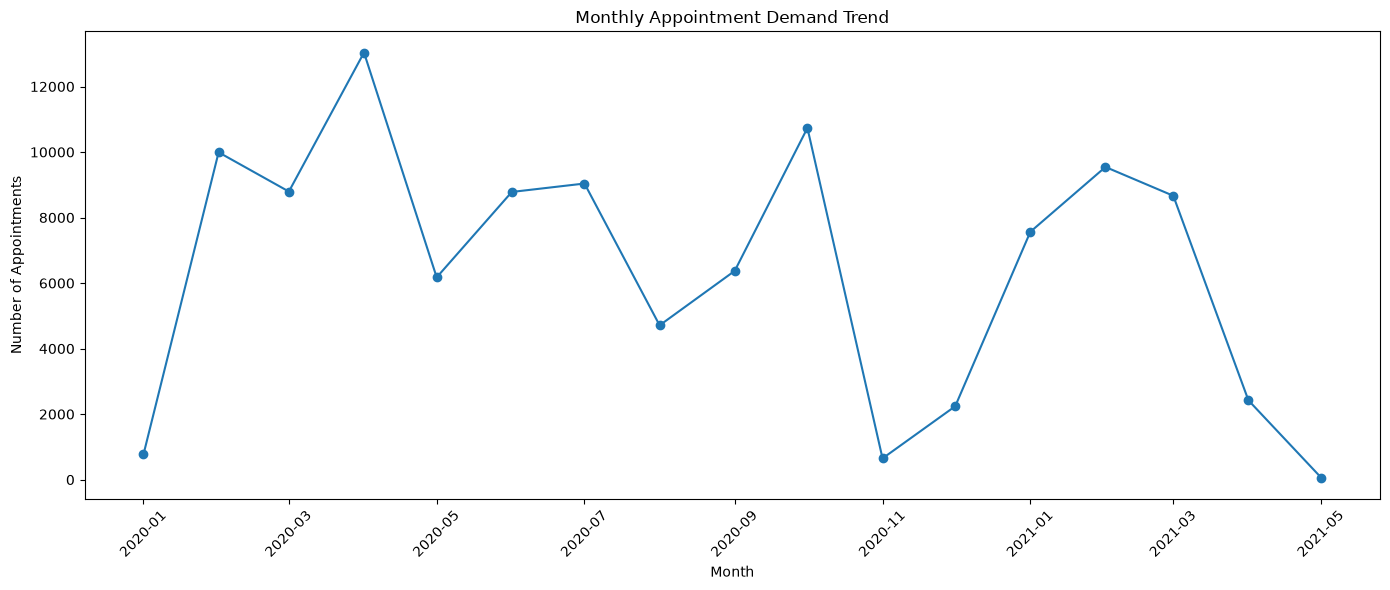

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_demand['appointment_month_date'],
    monthly_demand['appointment_volume'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Number of Appointments')
plt.title('Monthly Appointment Demand Trend')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [30]:
# Calculate demand share by specialty within each shift

staffing_share = staffing_table.copy()

for shift in ['morning', 'afternoon']:
    shift_total = staffing_share[shift].sum()
    staffing_share[f'{shift}_share_pct'] = (
        staffing_share[shift] / shift_total * 100
    )

print("Staffing demand share by specialty and shift:")
print(
    staffing_share[
        [
            'specialty',
            'morning',
            'morning_share_pct',
            'afternoon',
            'afternoon_share_pct'
        ]
    ].round(2).to_string(index=False)
)

Staffing demand share by specialty and shift:
           specialty  morning  morning_share_pct  afternoon  afternoon_share_pct
       psychotherapy    10737              29.42      17905                33.80
      speech therapy     8574              23.50      13747                25.95
       physiotherapy    10811              29.63      10190                19.24
occupational therapy     4126              11.31       7192                13.58
            pedagogo       17               0.05       3518                 6.64
                 enf     1601               4.39         80                 0.15
              assist      594               1.63         41                 0.08
   sem especialidade       30               0.08        294                 0.56


In [31]:
# Create staffing priority based on total historical appointment demand

staffing_plan = staffing_share[
    [
        'specialty',
        'morning',
        'afternoon',
        'Total Appointments',
        'morning_share_pct',
        'afternoon_share_pct'
    ]
].copy()

# Assign workload priority based on total appointment volume
staffing_plan['workload_priority'] = pd.cut(
    staffing_plan['Total Appointments'],
    bins=[-1, 5000, 15000, float('inf')],
    labels=['Low', 'Medium', 'High']
)

staffing_plan = staffing_plan.sort_values(
    'Total Appointments',
    ascending=False
)

print("Staffing Planning Table:")
print(
    staffing_plan.round(2).to_string(index=False)
)

Staffing Planning Table:
           specialty  morning  afternoon  Total Appointments  morning_share_pct  afternoon_share_pct workload_priority
       psychotherapy    10737      17905               28642              29.42                33.80              High
      speech therapy     8574      13747               22321              23.50                25.95              High
       physiotherapy    10811      10190               21001              29.63                19.24              High
occupational therapy     4126       7192               11318              11.31                13.58            Medium
            pedagogo       17       3518                3535               0.05                 6.64               Low
                 enf     1601         80                1681               4.39                 0.15               Low
              assist      594         41                 635               1.63                 0.08               Low
   sem especialidade   

<Figure size 1200x600 with 0 Axes>

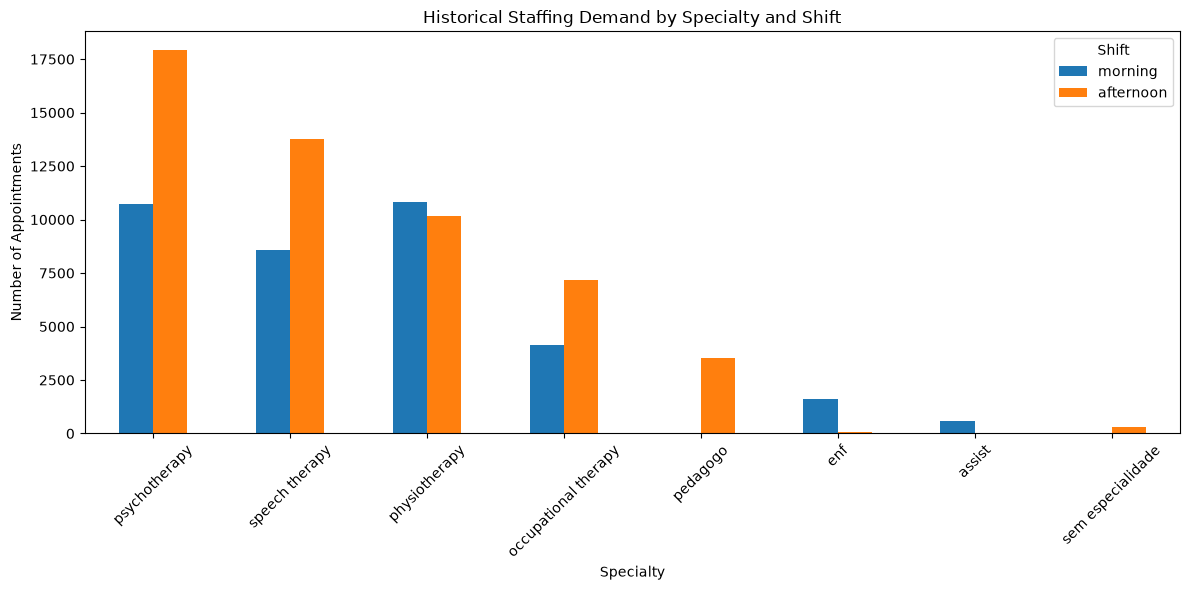

In [32]:
# Visualize historical staffing demand by specialty and shift

plt.figure(figsize=(12, 6))

staffing_plot = staffing_plan.set_index('specialty')[
    ['morning', 'afternoon']
]

staffing_plot.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.xlabel('Specialty')
plt.ylabel('Number of Appointments')
plt.title('Historical Staffing Demand by Specialty and Shift')
plt.xticks(rotation=45)
plt.legend(title='Shift')
plt.tight_layout()
plt.show()

## Business Insight — Intelligent Staffing Optimization

Historical appointment demand varies substantially across specialties and shifts, indicating that staffing requirements should be aligned with workload patterns.

### Key Findings

* **Psychotherapy** has the highest historical appointment volume, with 28,642 appointments.
* **Speech therapy** has 22,321 appointments and shows stronger afternoon demand.
* **Physiotherapy** has 21,001 appointments and shows relatively balanced demand across morning and afternoon shifts.
* **Occupational therapy** has 11,318 appointments, with higher afternoon demand.
* Some specialties have very low overall volume and may require more flexible staffing arrangements.

### Staffing Planning Approach

* Prioritize staffing capacity for high-volume specialties such as psychotherapy, speech therapy, and physiotherapy.
* Allocate relatively more afternoon capacity to psychotherapy, speech therapy, and occupational therapy based on historical demand.
* Maintain balanced morning and afternoon capacity for physiotherapy.
* Use flexible or shared staffing arrangements for lower-volume specialties.

### Forecasting Insight

The forecasting analysis showed that appointment volume changes substantially over time. The final 14-day forecast beyond the dataset's last observed date produced approximately 3–6 appointments per day, reflecting the very low appointment volume immediately before the end of the dataset.

Therefore, the forecast should be treated as a **historical forecasting scenario** rather than a current operational forecast. In a real healthcare environment, staffing forecasts should be retrained regularly using the latest appointment data.

### Business Value

Combining demand forecasting with specialty- and shift-level workload analysis can help management plan staffing capacity, balance workloads, and reduce the risk of allocating too much or too little capacity to individual services.

> Staffing recommendations are based on historical appointment volume. Actual staffing levels should additionally consider specialist availability, appointment duration, patient complexity, and operational constraints.


## Case 2 — Final Staffing Summary

| Specialty            | Morning Appointments | Afternoon Appointments | Total Appointments | Workload Priority |
| -------------------- | -------------------: | ---------------------: | -----------------: | ----------------- |
| Psychotherapy        |               10,737 |                 17,905 |             28,642 | High              |
| Speech therapy       |                8,574 |                 13,747 |             22,321 | High              |
| Physiotherapy        |               10,811 |                 10,190 |             21,001 | High              |
| Occupational therapy |                4,126 |                  7,192 |             11,318 | Medium            |
| Pedagogo             |                   17 |                  3,518 |              3,535 | Low               |
| Enf                  |                1,601 |                     80 |              1,681 | Low               |
| Assist               |                  594 |                     41 |                635 | Low               |
| Sem especialidade    |                   30 |                    294 |                324 | Low               |

**Key takeaway:** Historical demand is concentrated in psychotherapy, speech therapy, physiotherapy, and occupational therapy, while demand for the remaining specialties is considerably lower. Shift-level demand also varies by specialty, supporting workload-based staffing allocation.
